In [1]:
import numpy as np
import pandas as pd
import os
import glob
import itertools
import scanpy as sc
import natsort
import json

import matplotlib.pyplot as plt
import seaborn as sns

from scroutines import basicu
from scroutines import powerplots

In [2]:
class Bigtensor_lite():
    def __init__(self, f_data, f_meta):
        
        bigtensor = np.load(f_data)
        with open(f_meta, 'r') as fp:
            meta = json.load(fp)

        dim = len(meta['size'])
        
        if dim == 3:
            self.nf, self.nc, self.ng = meta['size']
            self.conds = np.array(meta['dim0'])
            self.types = np.array(meta['dim1'])
            self.genes = np.array(meta['dim2'])
            
        elif dim == 4:
            self.nf, _, self.nc, self.ng = meta['size']
            self.conds = np.array(meta['dim0'])
            self.types = np.array(meta['dim2'])
            self.genes = np.array(meta['dim3'])
            
            bigtensor = np.nanmean(bigtensor, axis=1)
            
        self.bt = bigtensor

        # self.conds_time = np.array([int(cond[1:-2]) for cond in self.conds])
        # self.conds_anno = np.array([cond[-2:] for cond in self.conds])
        # self.conds_color = pd.Series(self.palette).loc[self.conds_anno].values 
        
        return
    
    def get_conds_idx(self, query_conds): 
        """
        """
        conds_idx = basicu.get_index_from_array(self.conds, query_conds)
        assert np.any(conds_idx != -1)
        return conds_idx
            
    def get_types_idx(self, query_types):
        """
        """
        types_idx = basicu.get_index_from_array(self.types, query_types)
        assert np.any(types_idx != -1)
        return types_idx
            
    def get_genes_idx(self, query_genes):
        """
        """
        genes_idx = basicu.get_index_from_array(self.genes, query_genes)
        assert np.any(genes_idx != -1)
        return genes_idx
            
    
    def plot_one_lite(self, ax, selected_type, selected_gene, annotate=True, color='k'):
        """
        """
        type_idx = basicu.get_index_from_array(self.types, [selected_type])[0]
        gene_idx = basicu.get_index_from_array(self.genes, [selected_gene])[0]
        assert gene_idx != -1

        vals = self.bigtensor[:,:,type_idx, gene_idx] # cond by rep
        vals_mean = np.nanmean(vals, axis=1)


        ax.set_title(f'{selected_gene} in {selected_type}')
        
#         for anno in ['NR', 'DR', 'DL']:
#             marker = self.anno_marker_dict[anno]
#             sel = self.conds_anno == anno
#             if sel.sum() > 0:
                
#                 if anno == 'NR':
#                     ax.plot(self.conds_time[sel], vals_mean[sel], '-', color=color)

#                 ax.scatter(np.repeat(self.conds_time[sel], self.nr), vals[sel].reshape(-1,), 
#                            color=color,
#                            facecolors='none',
#                            marker=marker,
#                            label=anno,
#                           )

#         sns.despine(ax=ax)

#         if annotate:
#             handles, labels = ax.get_legend_handles_labels()
#             unique_labels = dict(zip(labels, handles))
#             ax.legend(unique_labels.values(), unique_labels.keys(), fontsize=12) # , bbox_to_anchor=(1,1))

#             ax.set_xlabel('Postnatal day (P)')
#             ax.set_ylabel('log2(CPM+1)')
        

In [3]:
ddir = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_dev_merged'
!ls $ddir

bigtensor_cheng22_subclass_v2.json  bigtensor_yoo25_subclass_v2.npy
bigtensor_cheng22_subclass_v2.npy   cheng22_astro.h5ad
bigtensor_gao25_subclass.json	    gao25_astro.h5ad
bigtensor_gao25_subclass.npy	    yoo25_astro.h5ad
bigtensor_yoo25_subclass_v2.json


In [4]:
adata1 = sc.read(os.path.join(ddir, 'cheng22_astro.h5ad'))
adata2 = sc.read(os.path.join(ddir, 'gao25_astro.h5ad'))
adata3 = sc.read(os.path.join(ddir, 'yoo25_astro.h5ad'))

print(adata1)
print(adata2)
print(adata3)

AnnData object with n_obs × n_vars = 19362 × 53801
    obs: 'Class_broad', 'Doublet', 'Doublet Score', 'batch', 'leiden', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'biosample'
AnnData object with n_obs × n_vars = 13766 × 32285
    obs: 'Unnamed: 0', 'subcluster_id', 'subcluster_label', 'cluster_label', 'subclass_label', 'class_label', 'subcluster_prob', 'cluster_probability', 'subclass_probability', 'class_probability', 'library_prep', 'roi', 'sex', 'donor_name', 'age_label', 'cellNames'
AnnData object with n_obs × n_vars = 14028 × 16572
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'cond', 'biosample'
    var: 'feature_types'


# select shared genes

In [5]:
import re

In [6]:
# shared and normal genes
genes_overlap = np.intersect1d(adata1.var.index.values, adata2.var.index.values)
genes_overlap = np.intersect1d(genes_overlap, adata3.var.index.values)
print(genes_overlap.shape)

# remove mitochondrial genes 
mask = np.char.startswith(genes_overlap.astype(str), 'mt-')
genes_overlap = genes_overlap[~mask]
print(genes_overlap.shape)

# remove 'a'
pattern = re.compile(r'^[a-z]')
mask = np.array([bool(pattern.match(s)) for s in genes_overlap.astype(str)])
genes_overlap = genes_overlap[~mask]
print(genes_overlap.shape)
genes_overlap

(16570,)
(16558,)
(16557,)


array(['0610005C13Rik', '0610009B22Rik', '0610009E02Rik', ..., 'Zyx',
       'Zzef1', 'Zzz3'], dtype=object)

In [7]:
adata1 = adata1[:,genes_overlap]
adata2 = adata2[:,genes_overlap]
adata3 = adata3[:,genes_overlap]

print(adata1)
print(adata2)
print(adata3)

View of AnnData object with n_obs × n_vars = 19362 × 16557
    obs: 'Class_broad', 'Doublet', 'Doublet Score', 'batch', 'leiden', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'biosample'
View of AnnData object with n_obs × n_vars = 13766 × 16557
    obs: 'Unnamed: 0', 'subcluster_id', 'subcluster_label', 'cluster_label', 'subclass_label', 'class_label', 'subcluster_prob', 'cluster_probability', 'subclass_probability', 'class_probability', 'library_prep', 'roi', 'sex', 'donor_name', 'age_label', 'cellNames'
View of AnnData object with n_obs × n_vars = 14028 × 16557
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'cond', 'biosample'
    var: 'feature_types'


# select adult stage samples

In [8]:
adata1.obs['cond'] = adata1.obs['biosample'].apply(lambda x: ''.join(x.split('_')[:-1]).upper()) # .biosample.cat.categories

/tmp/ipykernel_6329/3883529802.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata1.obs['cond'] = adata1.obs['biosample'].apply(lambda x: ''.join(x.split('_')[:-1]).upper()) # .biosample.cat.categories


In [9]:
adata1_adlt = adata1[adata1.obs['cond'].isin(['P28', 'P38'])]
adata1_adlt

View of AnnData object with n_obs × n_vars = 3653 × 16557
    obs: 'Class_broad', 'Doublet', 'Doublet Score', 'batch', 'leiden', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'biosample', 'cond'

In [10]:
adata2_adlt = adata2[adata2.obs['age_label'].isin(['P56', 'P58'])]
adata2_adlt

View of AnnData object with n_obs × n_vars = 3390 × 16557
    obs: 'Unnamed: 0', 'subcluster_id', 'subcluster_label', 'cluster_label', 'subclass_label', 'class_label', 'subcluster_prob', 'cluster_probability', 'subclass_probability', 'class_probability', 'library_prep', 'roi', 'sex', 'donor_name', 'age_label', 'cellNames'

In [11]:
adata3_adlt = adata3[adata3.obs['Age'].isin(['P21'])]
adata3_adlt

View of AnnData object with n_obs × n_vars = 884 × 16557
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'cond', 'biosample'
    var: 'feature_types'

# first round of study individually

In [12]:
adata = adata1_adlt.copy()

/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


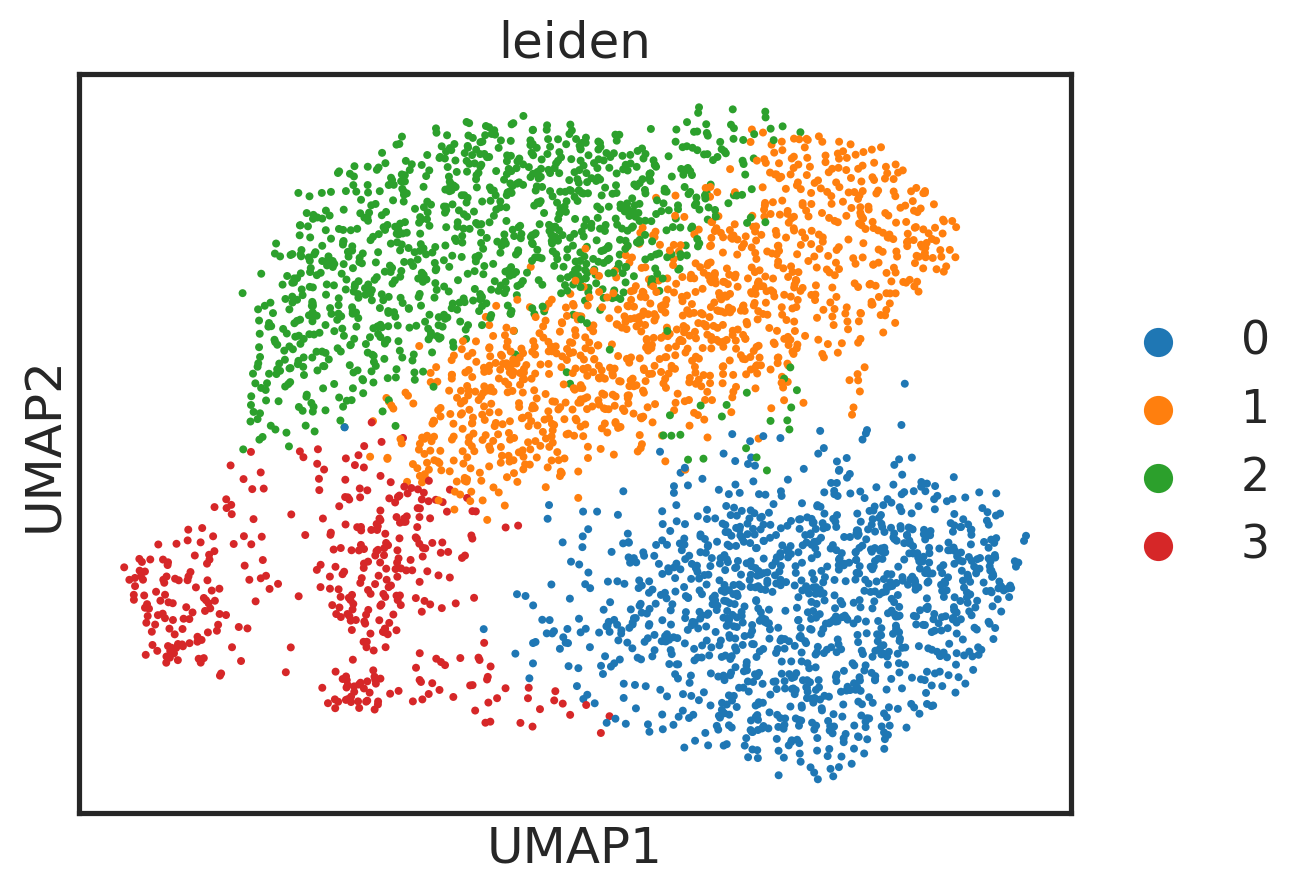

In [13]:
# Basic filtering: cells with <200 genes, genes in <3 cells
sc.pp.filter_cells(adata, min_genes=200) 
sc.pp.filter_genes(adata, min_cells=3)

# Total count normalization and log transformation
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Identify and subset to highly variable genes
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable].copy()

# Scale data to unit variance and zero mean
sc.pp.scale(adata, max_value=10)

# Dimensionality reduction (PCA)
sc.tl.pca(adata, svd_solver='arpack')

# Compute the neighborhood graph using PCA representation
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30)

# Compute UMAP for 2D visualization
sc.tl.umap(adata)

# Cluster the neighborhood graph using the Leiden algorithm
sc.tl.leiden(adata, resolution=0.5)

# Plot the results
sc.pl.umap(adata, color=['leiden'])


/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(


/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


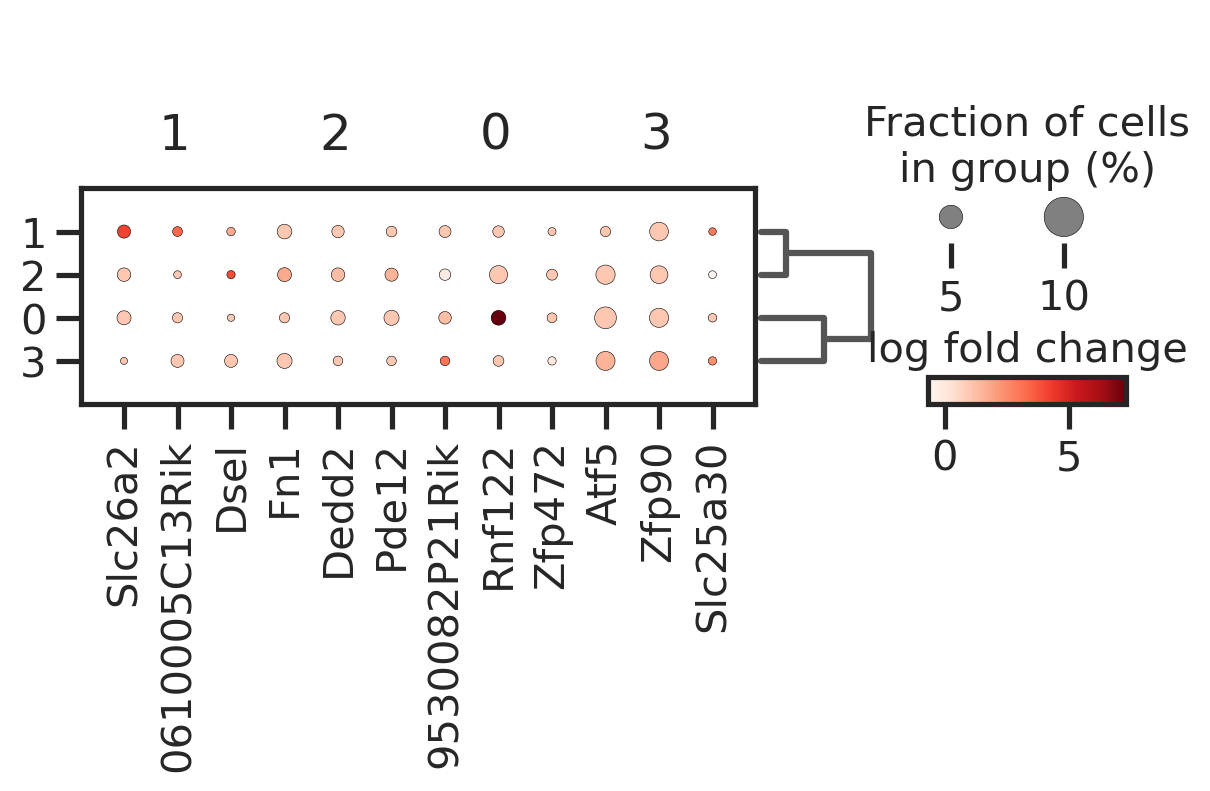

In [14]:
# Compute differential expression (Wilcoxon rank-sum test is default and robust)
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')

# View the top 5 genes for each cluster in a table
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
# pd.DataFrame({group: result['names'][group][:5] for group in groups})

# Plot the top 3 genes per cluster
sc.pl.rank_genes_groups_dotplot(adata, n_genes=3, values_to_plot='logfoldchanges', min_logfoldchange=1)



In [15]:
adata.var_names.shape

(2881,)

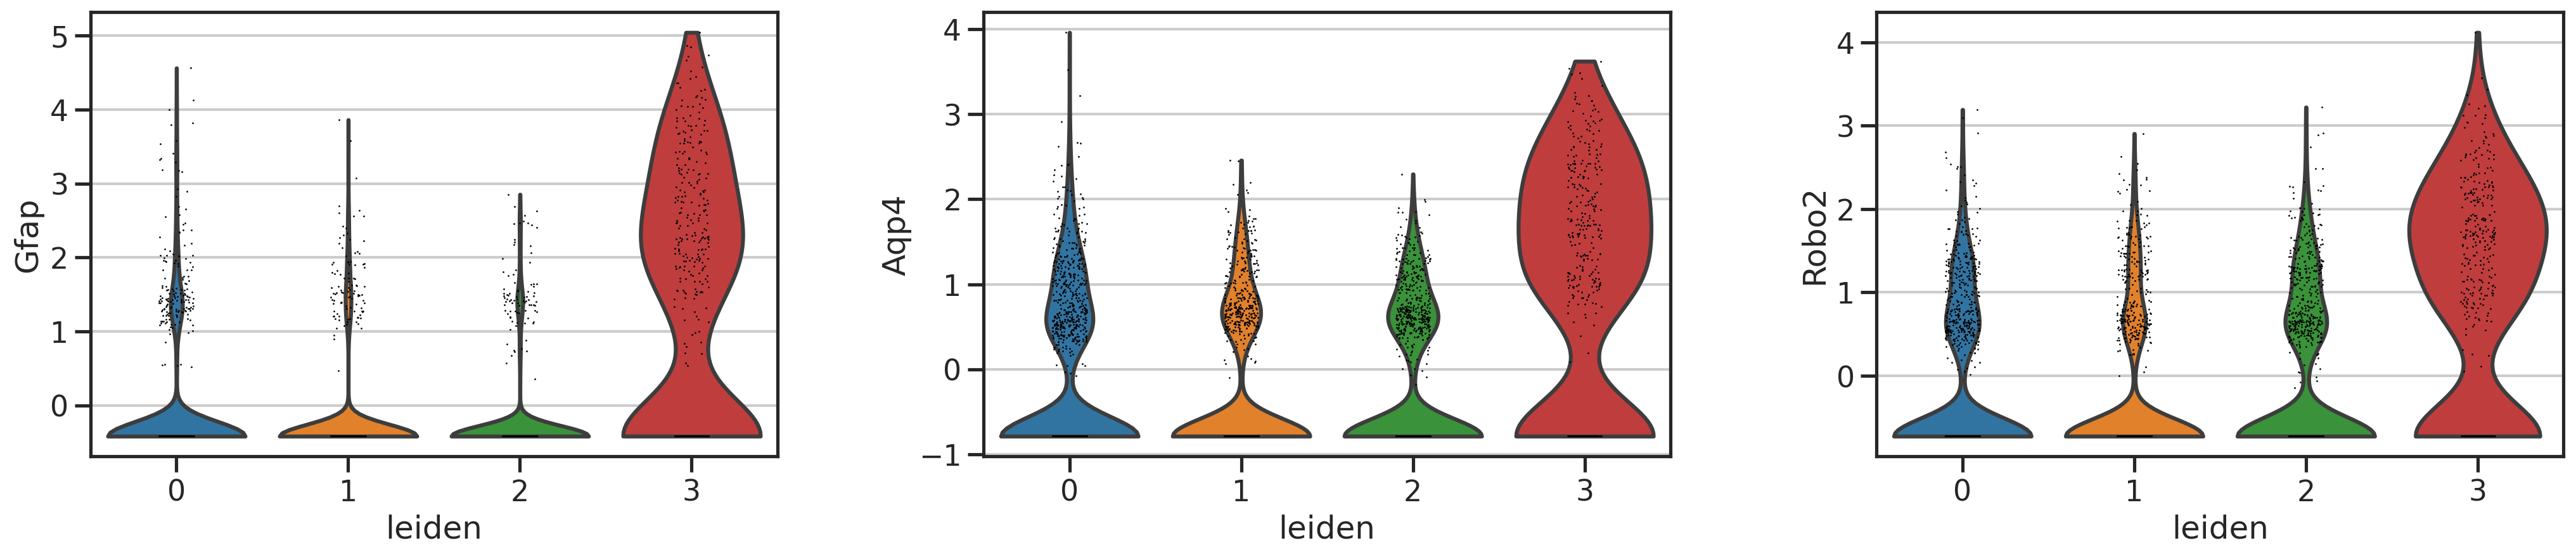

In [16]:
sc.pl.violin(adata, ['Gfap', 'Aqp4', 'Robo2'], groupby='leiden')

# # Extract results for all clusters into a single DataFrame
# marker_df = sc.get.rank_genes_groups_df(adata, group=None)
# marker_df.to_csv("cluster_markers.csv")

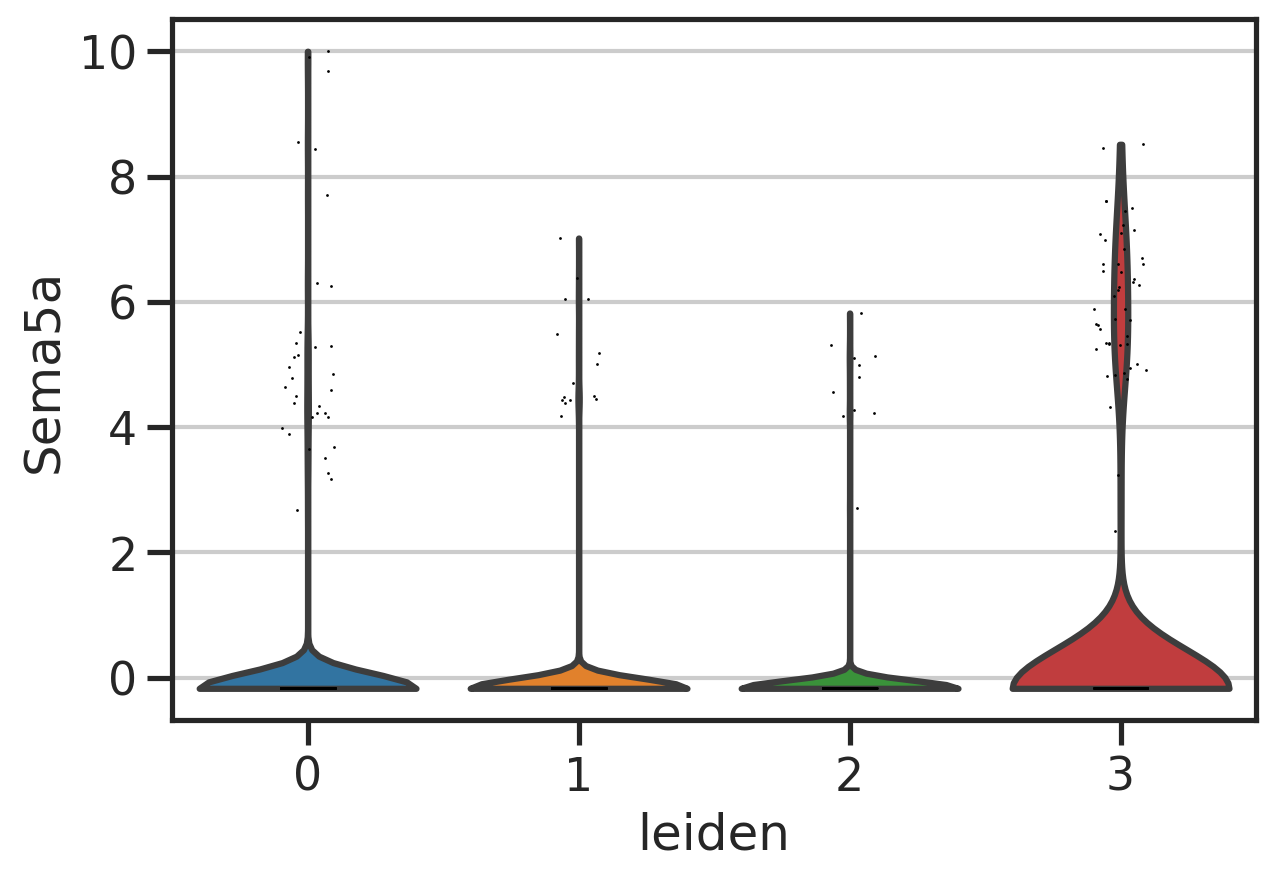

In [17]:
sc.pl.violin(adata, ['Sema5a', ], groupby='leiden')

# first round of study individually

In [18]:
adata = adata2_adlt.copy()

/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


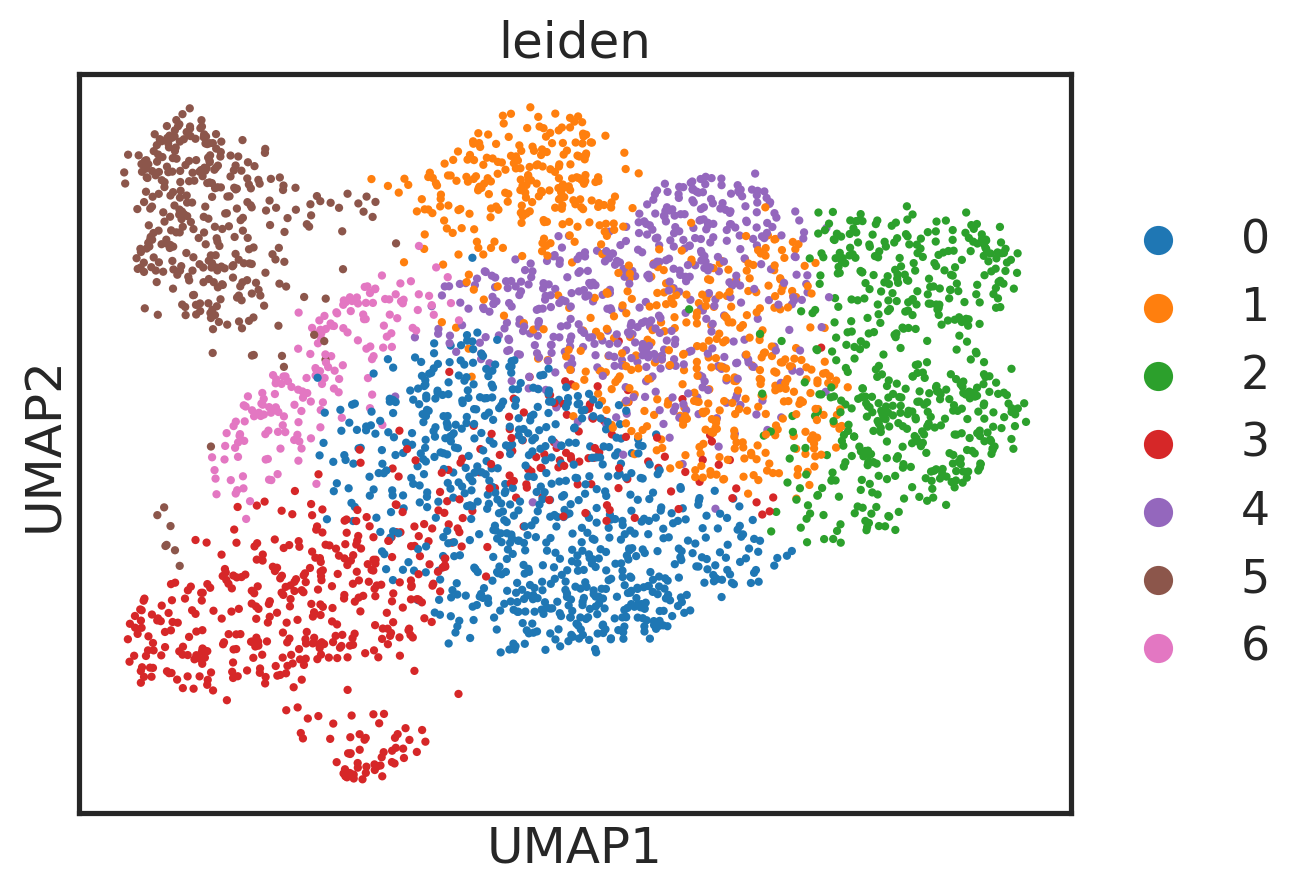

In [19]:
# Basic filtering: cells with <200 genes, genes in <3 cells
sc.pp.filter_cells(adata, min_genes=200) 
sc.pp.filter_genes(adata, min_cells=3)

# Total count normalization and log transformation
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Identify and subset to highly variable genes
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable].copy()

# Scale data to unit variance and zero mean
sc.pp.scale(adata, max_value=10)

# Dimensionality reduction (PCA)
sc.tl.pca(adata, svd_solver='arpack')

# Compute the neighborhood graph using PCA representation
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30)

# Compute UMAP for 2D visualization
sc.tl.umap(adata)

# Cluster the neighborhood graph using the Leiden algorithm
sc.tl.leiden(adata, resolution=0.5)

# Plot the results
sc.pl.umap(adata, color=['leiden'])


/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  se

/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


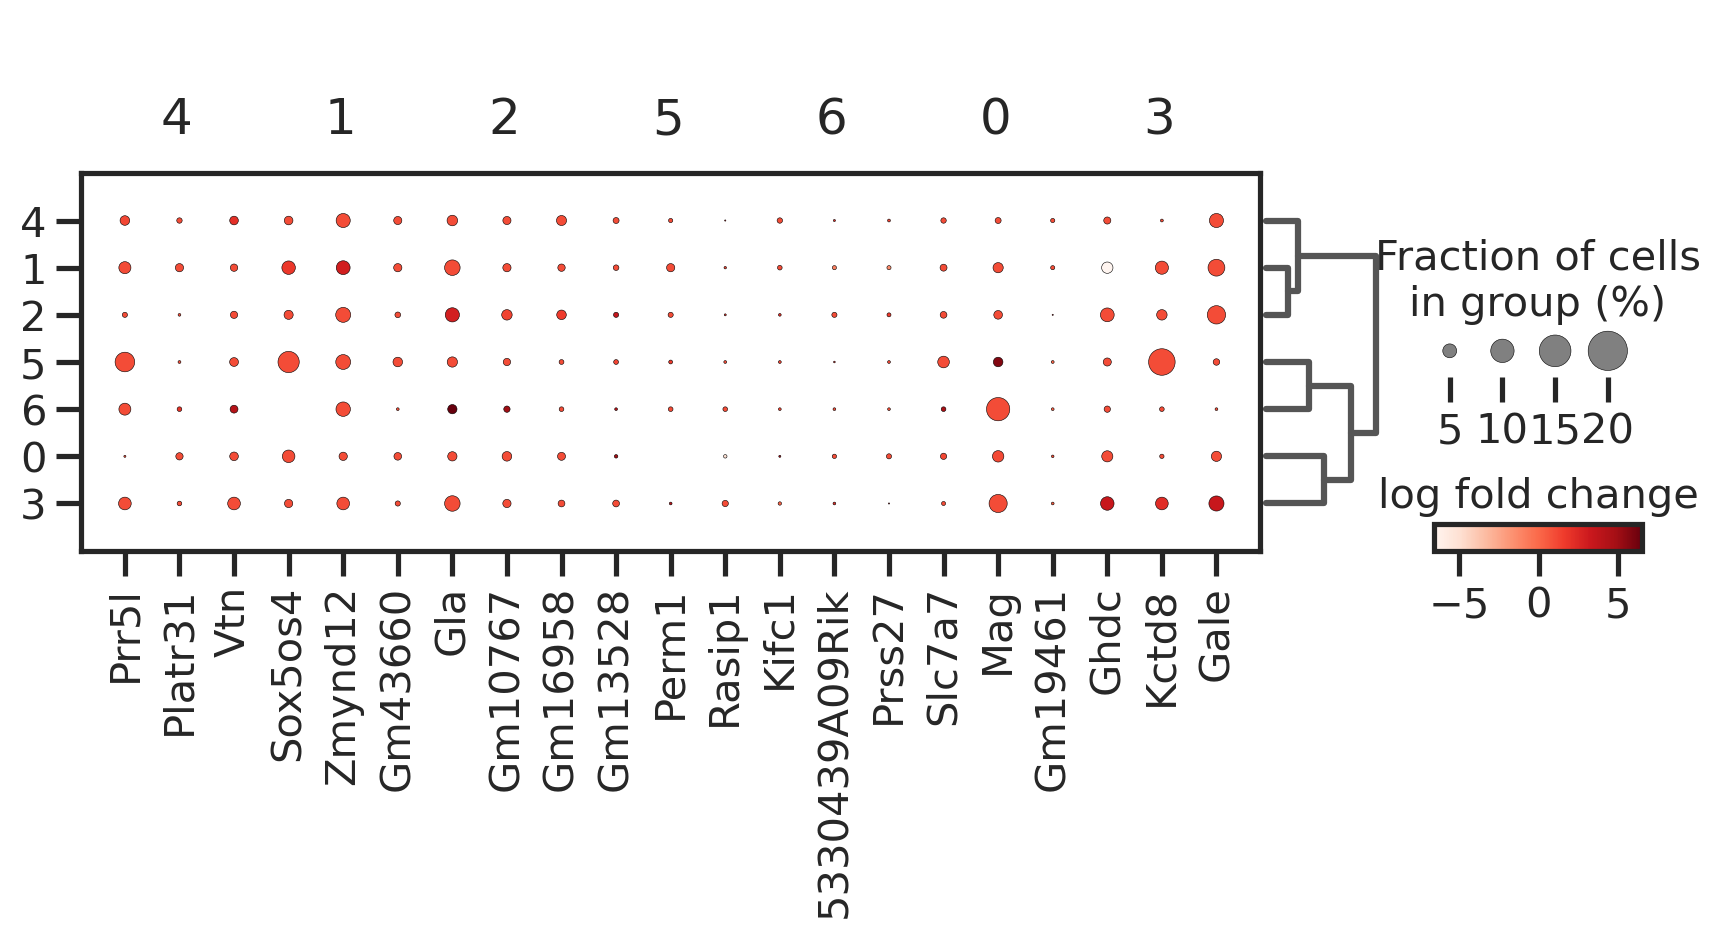

In [20]:
# Compute differential expression (Wilcoxon rank-sum test is default and robust)
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')

# View the top 5 genes for each cluster in a table
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
# pd.DataFrame({group: result['names'][group][:5] for group in groups})

# Plot the top 3 genes per cluster
sc.pl.rank_genes_groups_dotplot(adata, n_genes=3, values_to_plot='logfoldchanges', min_logfoldchange=1)



In [21]:
adata.var_names.shape

(2646,)

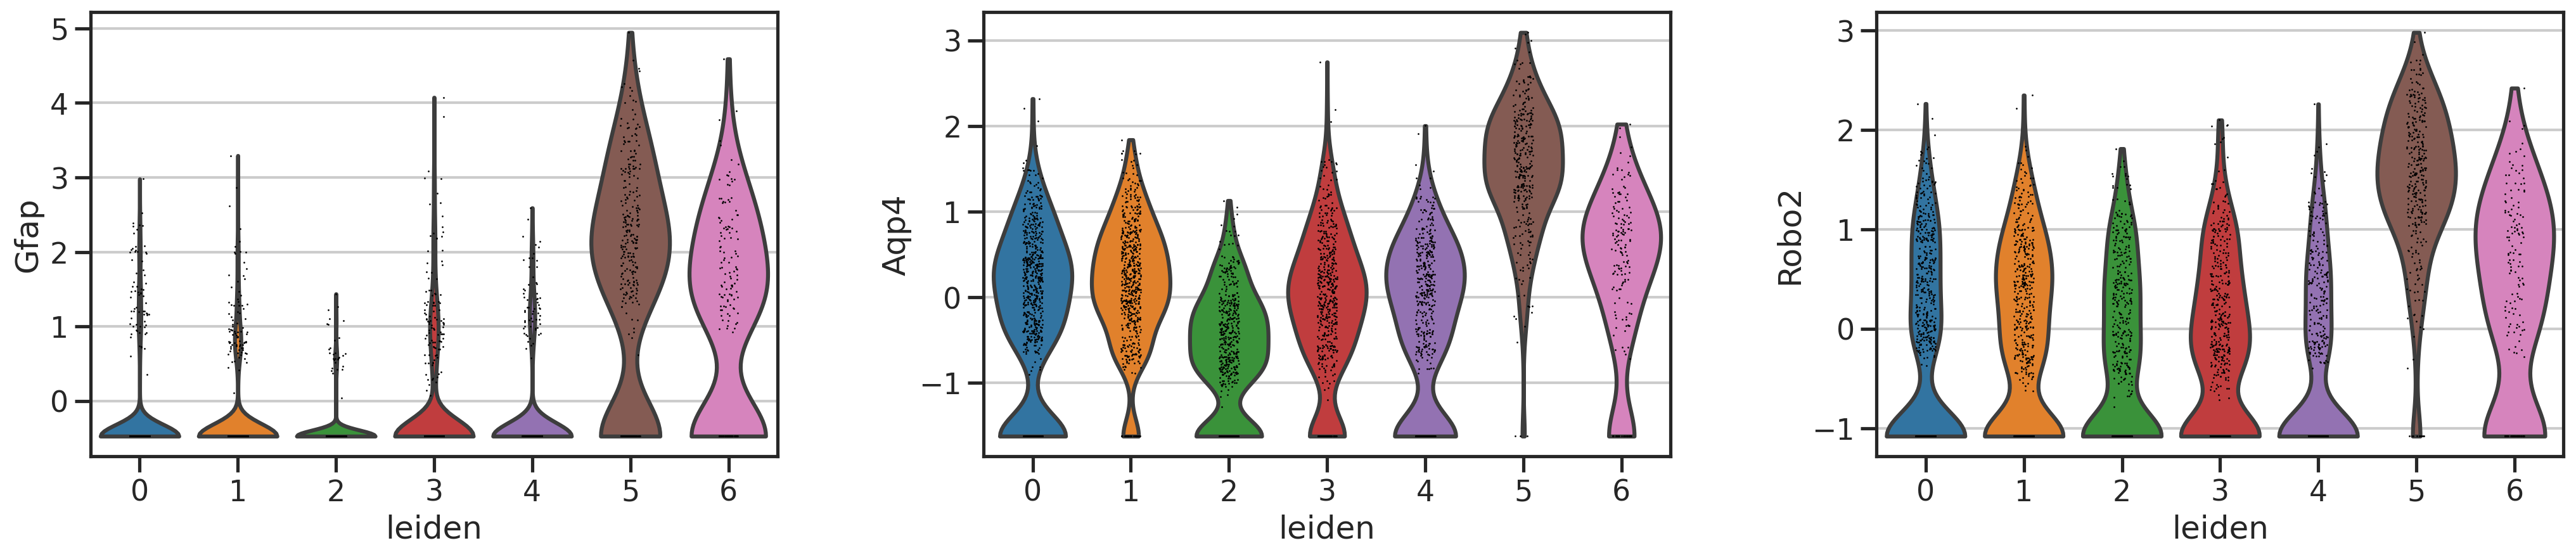

In [22]:
sc.pl.violin(adata, ['Gfap', 'Aqp4', 'Robo2'], groupby='leiden')

# # Extract results for all clusters into a single DataFrame
# marker_df = sc.get.rank_genes_groups_df(adata, group=None)
# marker_df.to_csv("cluster_markers.csv")

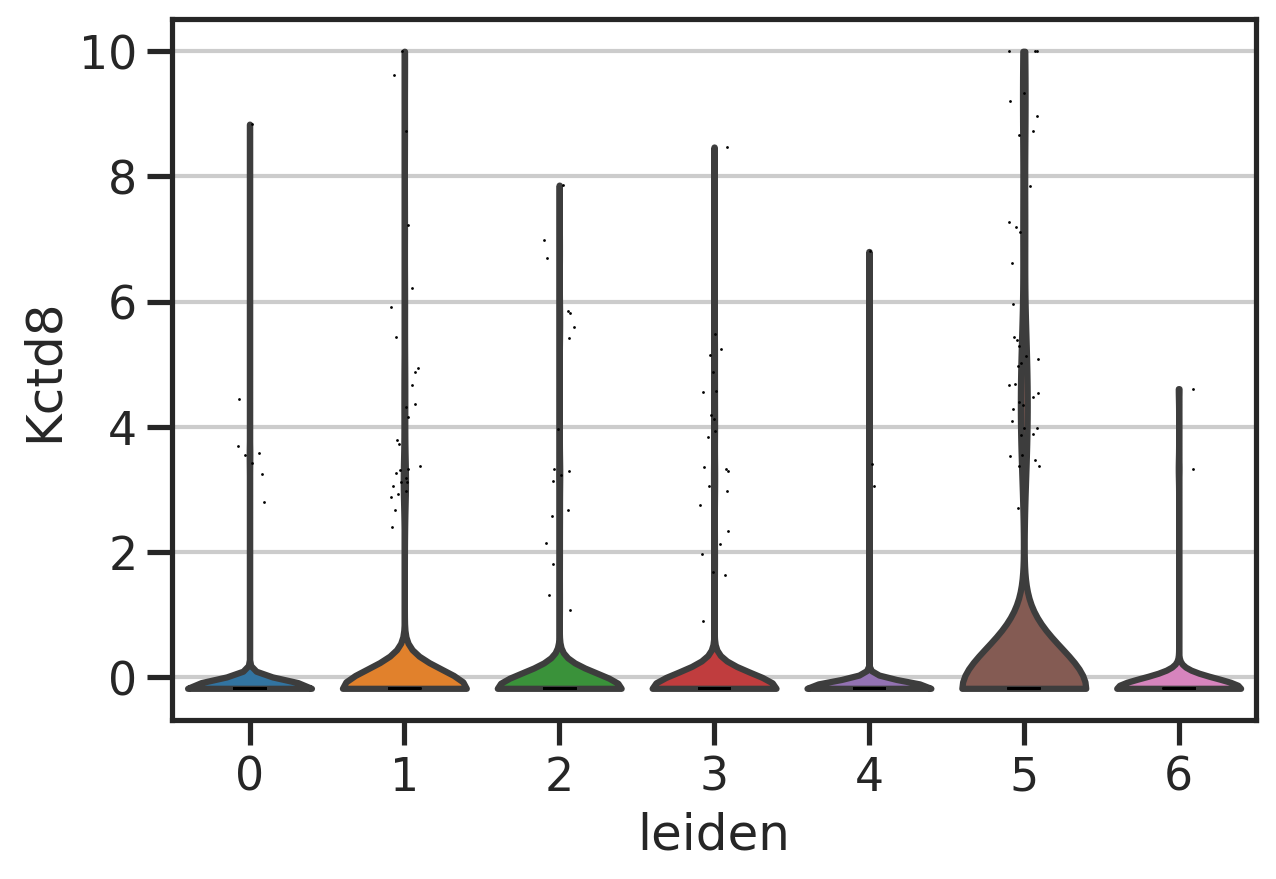

In [23]:
sc.pl.violin(adata, ['Kctd8', ], groupby='leiden')

In [24]:
adata.obs.cluster_label

AAACATGCATCTAGCA-L8XR_220331_02_A11-1170314855    5228_Astro-TE NN_4
AAACCGGCAAGCTTTG-L8XR_220331_02_A11-1170314855    5225_Astro-TE NN_3
AAACCGGCAGGCATCT-L8XR_220331_02_A11-1170314855    5225_Astro-TE NN_3
AAACCGGCATAATCGT-L8XR_220331_02_A11-1170314855    5225_Astro-TE NN_3
AAAGCCGCAGCTAACC-L8XR_220331_02_A11-1170314855    5225_Astro-TE NN_3
                                                         ...        
TTGTTGCGTCCCGGAA-L8XR_220721_02_D06-1196254077    5225_Astro-TE NN_3
TTGTTGTTCGATTTAG-L8XR_220721_02_D06-1196254077    5225_Astro-TE NN_3
TTTAGGATCAGGCTAT-L8XR_220721_02_D06-1196254077    5225_Astro-TE NN_3
TTTCATCAGCAGGCCT-L8XR_220721_02_D06-1196254077    5225_Astro-TE NN_3
TTTGCGACATTAAGCT-L8XR_220721_02_D06-1196254077    5225_Astro-TE NN_3
Name: cluster_label, Length: 3390, dtype: category
Categories (3, object): ['5218_Astro-TE NN_1', '5225_Astro-TE NN_3', '5228_Astro-TE NN_4']

/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


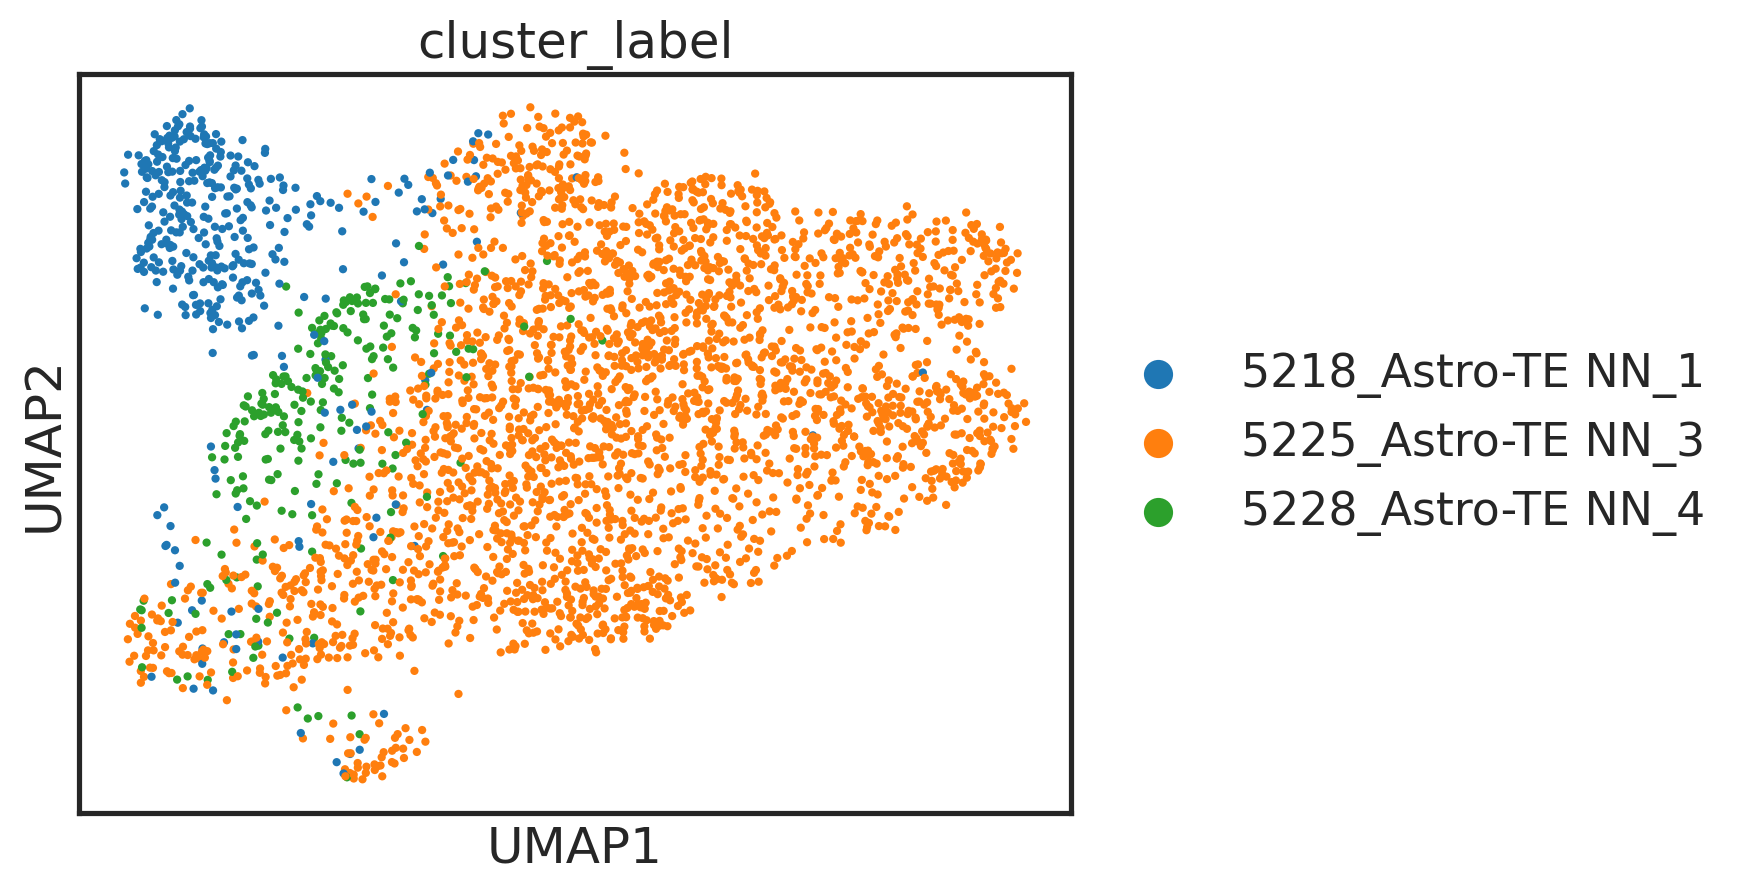

In [33]:
sc.pl.umap(adata, color=['cluster_label'])

/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


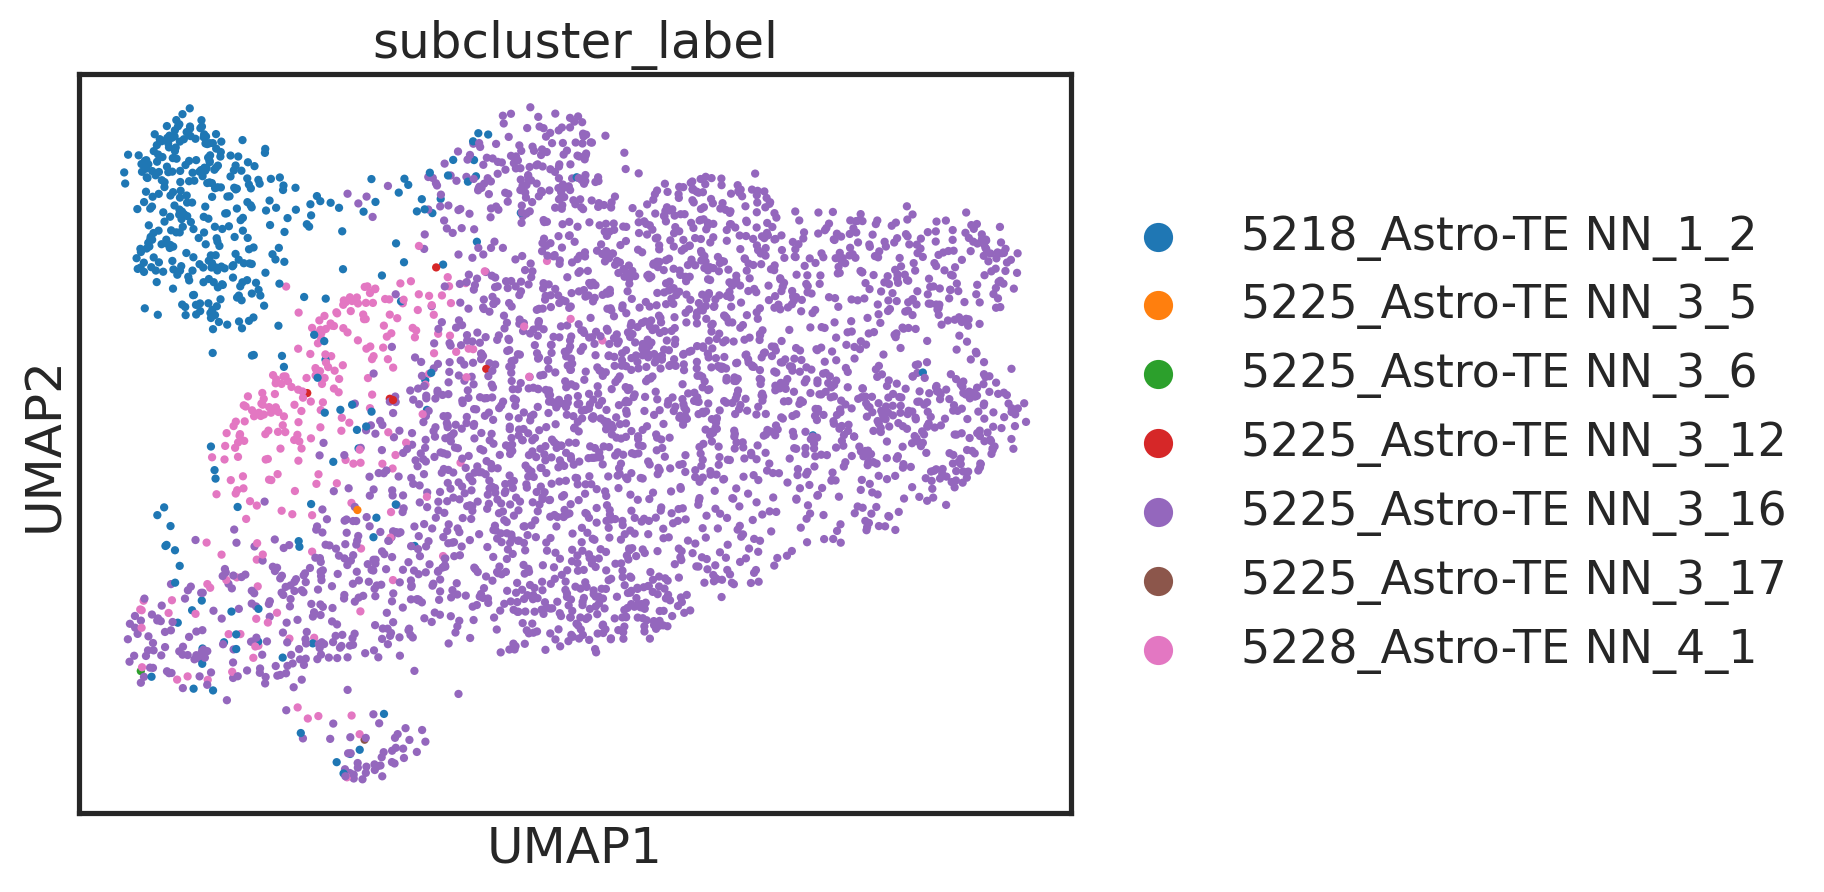

In [34]:
sc.pl.umap(adata, color=['subcluster_label'])

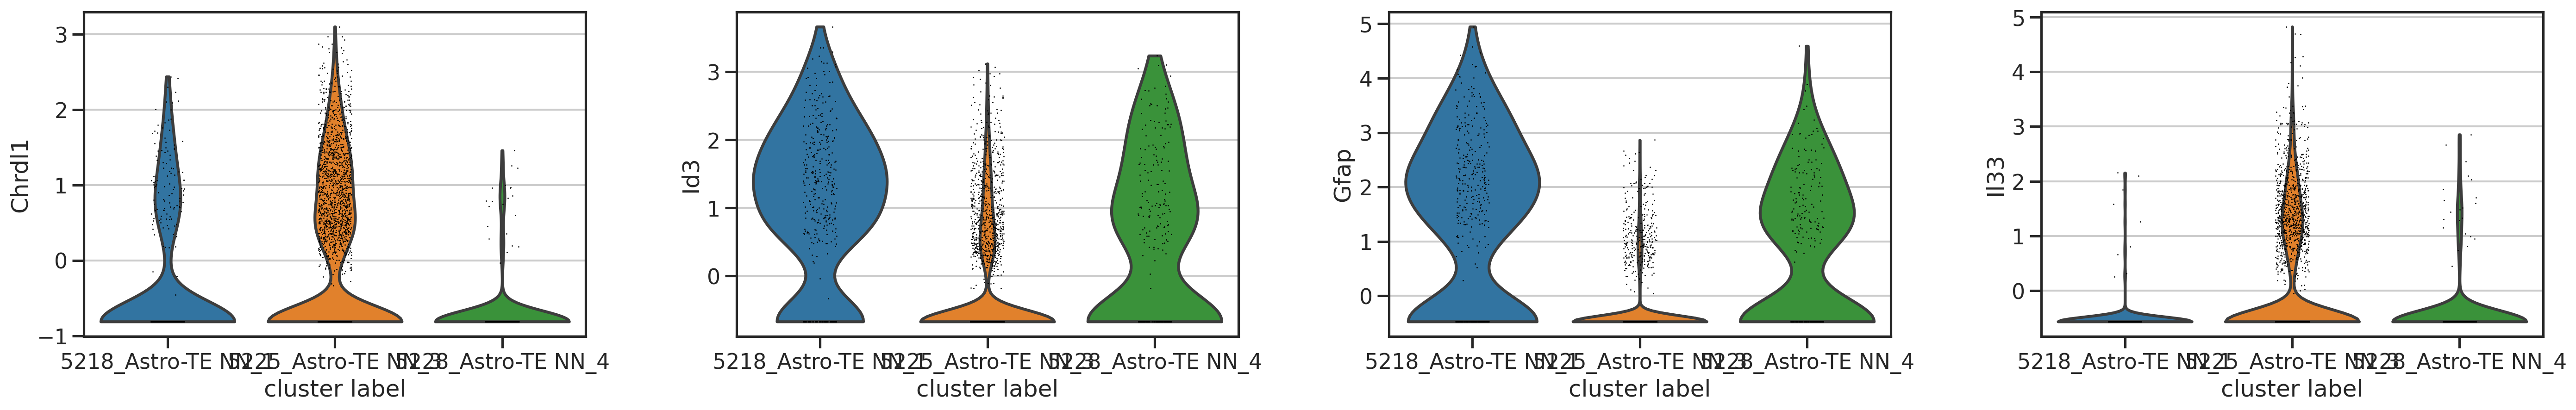

In [35]:
sc.pl.violin(adata, ['Chrdl1', 'Id3', 'Gfap', 'Il33'], groupby='cluster_label')

# first round of study individually

In [ ]:
adata = adata3_adlt.copy()

In [ ]:
# Basic filtering: cells with <200 genes, genes in <3 cells
sc.pp.filter_cells(adata, min_genes=200) 
sc.pp.filter_genes(adata, min_cells=3)

# Total count normalization and log transformation
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Identify and subset to highly variable genes
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable].copy()

# Scale data to unit variance and zero mean
sc.pp.scale(adata, max_value=10)

# Dimensionality reduction (PCA)
sc.tl.pca(adata, svd_solver='arpack')

# Compute the neighborhood graph using PCA representation
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30)

# Compute UMAP for 2D visualization
sc.tl.umap(adata)

# Cluster the neighborhood graph using the Leiden algorithm
sc.tl.leiden(adata, resolution=0.5)

# Plot the results
sc.pl.umap(adata, color=['leiden'])


In [ ]:
# Compute differential expression (Wilcoxon rank-sum test is default and robust)
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')

# View the top 5 genes for each cluster in a table
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
# pd.DataFrame({group: result['names'][group][:5] for group in groups})

# Plot the top 3 genes per cluster
sc.pl.rank_genes_groups_dotplot(adata, n_genes=3, values_to_plot='logfoldchanges', min_logfoldchange=1)



In [ ]:
adata.var_names.shape

In [ ]:
sc.pl.violin(adata, ['Gfap', 'Aqp4', 'Robo2'], groupby='leiden')

# # Extract results for all clusters into a single DataFrame
# marker_df = sc.get.rank_genes_groups_df(adata, group=None)
# marker_df.to_csv("cluster_markers.csv")

In [ ]:
sc.pl.violin(adata, ['Trpm3', 'Gria2', 'Gpc5'], groupby='leiden')